In [52]:
import pandas as pd
import numpy as np
from utils import plot
from scipy.stats import pearsonr
from scipy.stats import pearsonr, spearmanr
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

In [53]:
df = pd.read_csv('wbtc_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values
timestamps = df['timestamp'].values

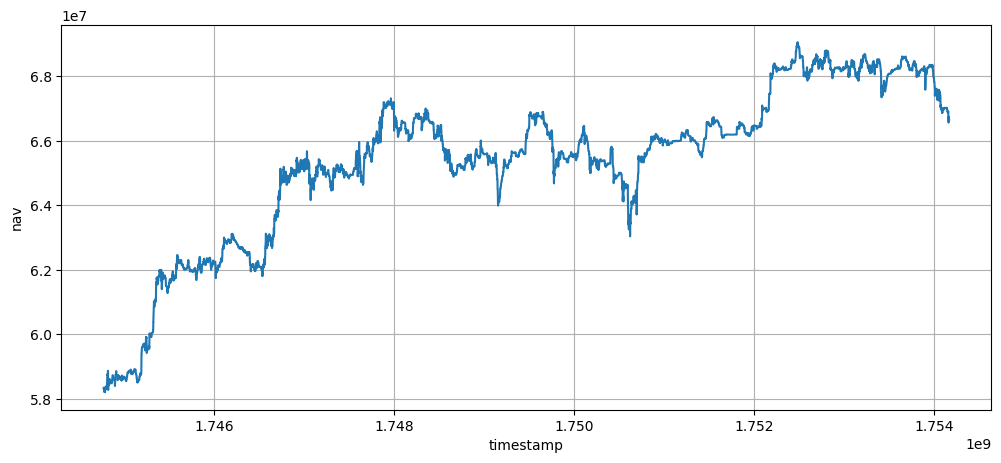

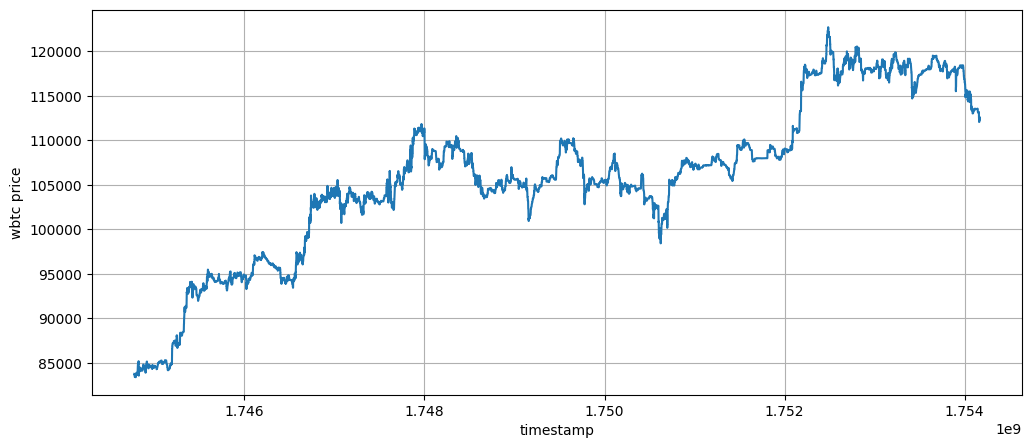

In [54]:
plot(
    series = [nav],
    times = timestamps,
    x = 'timestamp',
    y = 'nav'
)

plot(
    series = [vol_token_price],
    times = timestamps,
    x = 'timestamp',
    y = 'wbtc price'
)

In [55]:
corr, p_value = pearsonr(nav, vol_token_price)
print(corr, p_value)

0.9883557500286269 0.0


In [56]:
def diagnose_timeseries(x, y, max_lag=5):
    print("=== TIME SERIES DIAGNOSTICS (Compact) ===")

    # --- Basic checks
    x, y = np.asarray(x), np.asarray(y)
    assert x.shape == y.shape, "Series must have same length"
    n = len(x)
    print(f"Length: {n}")

    # --- Log returns
    rx = np.diff(np.log(x))
    ry = np.diff(np.log(y))

    # --- Correlations
    lvl_corr = np.corrcoef(x, y)[0, 1]
    ret_corr = np.corrcoef(rx, ry)[0, 1]
    print(f"Level Corr:   {lvl_corr:.4f}")
    print(f"Return Corr:  {ret_corr:.4f}")

    # --- Pearson & Spearman (returns)
    p, p_pv = pearsonr(rx, ry)
    s, s_pv = spearmanr(rx, ry)
    print(f"Pearson (returns):  {p:.4f}  p={p_pv:.2e}")
    print(f"Spearman (returns): {s:.4f}  p={s_pv:.2e}")

    # --- Stationarity (ADF)
    adf_x = adfuller(x)
    adf_y = adfuller(y)
    print(f"ADF x (levels): p={adf_x[1]:.3e}")
    print(f"ADF y (levels): p={adf_y[1]:.3e}")

    # --- Cointegration test
    c_stat, c_pv, _ = coint(x, y)
    print(f"Cointegration (Engle–Granger): p={c_pv:.3e}")

    # --- Lag structure (cross-corr on returns)
    print("Cross-corr at lags (returns):")
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            c = np.corrcoef(rx[:lag], ry[-lag:])[0, 1]
        elif lag > 0:
            c = np.corrcoef(rx[lag:], ry[:-lag])[0, 1]
        else:
            c = np.corrcoef(rx, ry)[0, 1]
        print(f"  lag {lag:+d}: {c:.4f}")

    # --- (Optional) Granger causality on returns
    print("Granger causality (returns):")
    try:
        gr = grangercausalitytests(np.column_stack([rx, ry]), maxlag=2, verbose=False)
        for lag in range(1, 3):
            pv = gr[lag][0]['ssr_ftest'][1]
            print(f"  x -> y (lag {lag}): p={pv:.3e}")
        gr = grangercausalitytests(np.column_stack([ry, rx]), maxlag=2, verbose=False)
        for lag in range(1, 3):
            pv = gr[lag][0]['ssr_ftest'][1]
            print(f"  y -> x (lag {lag}): p={pv:.3e}")
    except Exception as e:
        print("  Granger skipped:", e)

    print("=== END ===")

In [57]:
diagnose_timeseries(vol_token_price, nav)

=== TIME SERIES DIAGNOSTICS (Compact) ===
Length: 48180
Level Corr:   0.9884
Return Corr:  0.9915
Pearson (returns):  0.9915  p=0.00e+00
Spearman (returns): 0.9547  p=0.00e+00
ADF x (levels): p=1.179e-01
ADF y (levels): p=3.300e-02
Cointegration (Engle–Granger): p=6.272e-01
Cross-corr at lags (returns):
  lag -5: 0.0574
  lag -4: 0.0651
  lag -3: 0.0900
  lag -2: 0.1250
  lag -1: 0.2325
  lag +0: 0.9915
  lag +1: 0.2329
  lag +2: 0.1251
  lag +3: 0.0898
  lag +4: 0.0653
  lag +5: 0.0574
Granger causality (returns):
  x -> y (lag 1): p=1.944e-02
  x -> y (lag 2): p=3.186e-04
  y -> x (lag 1): p=1.558e-02
  y -> x (lag 2): p=2.032e-03
=== END ===


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [58]:
def simulate_correlated_gbm(n, dt, S10, S20, mu1, mu2, sigma1, sigma2, rho, seed=None):
    rng = np.random.default_rng(seed)
    Z1 = rng.standard_normal(n)
    Z2i = rng.standard_normal(n)
    Z2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2i

    r1 = (mu1 - 0.5 * sigma1**2) * dt + sigma1 * np.sqrt(dt) * Z1
    r2 = (mu2 - 0.5 * sigma2**2) * dt + sigma2 * np.sqrt(dt) * Z2

    S1 = np.empty(n + 1); S2 = np.empty(n + 1)
    S1[0], S2[0] = S10, S20
    S1[1:] = S10 * np.exp(np.cumsum(r1))
    S2[1:] = S20 * np.exp(np.cumsum(r2))

    return S1, S2, r1, r2

c:\Proga\leverege_simul\for_server\model_train\statistic\utils.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


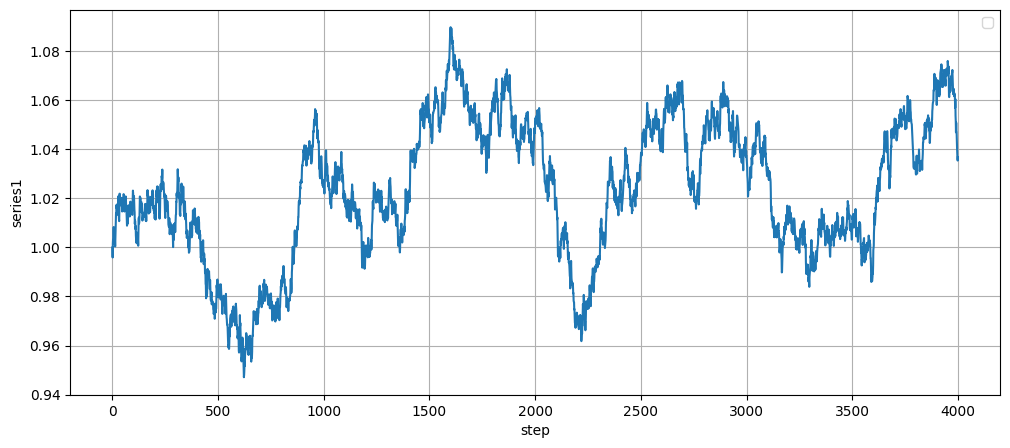

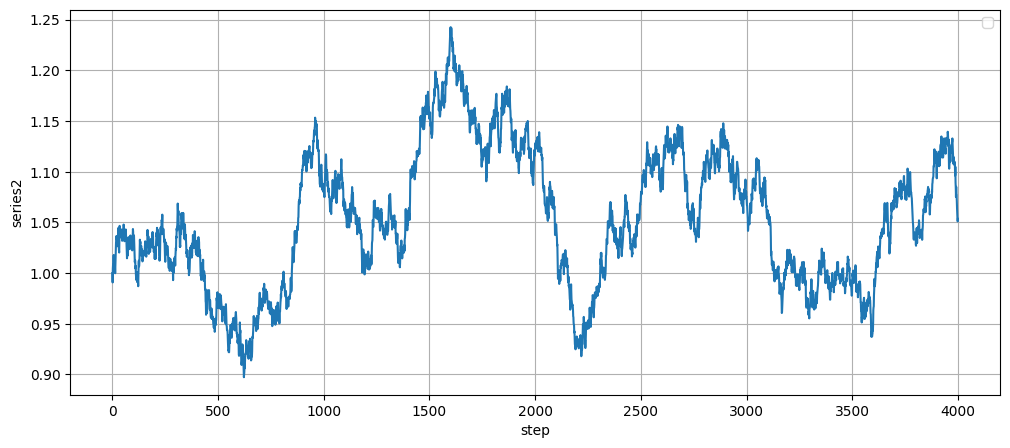

"plot(\n    [s1/s2],\n    'step',\n    'series2'\n)"

In [59]:
s1, s2, _, _ = simulate_correlated_gbm(
    n = 4000,
    dt = 1/250,
    S10 = 1,
    S20 = 1,
    mu1 = 0,
    mu2 = 0,
    sigma1 = 0.038,
    sigma2 = 0.085,
    rho = 0.9915
)

plot(
    [s1],
    'step',
    'series1'
)

plot(
    [s2],
    'step',
    'series2'
)

"""plot(
    [s1/s2],
    'step',
    'series2'
)"""

In [60]:
print(np.std(np.log(nav)))
print(np.std(np.log(vol_token_price)))

0.03810072808687429
0.08522254220295641


In [61]:
def simulate_gbm(n, dt, S10, mu1, sigma1, seed=None):
    rng = np.random.default_rng(seed)
    Z1 = rng.standard_normal(n)
    r1 = (mu1 - 0.5 * sigma1**2) * dt + sigma1 * np.sqrt(dt) * Z1
    S1 = np.empty(n + 1)
    S1[0] = S10
    S1[1:] = S10 * np.exp(np.cumsum(r1))

    return S1, r1

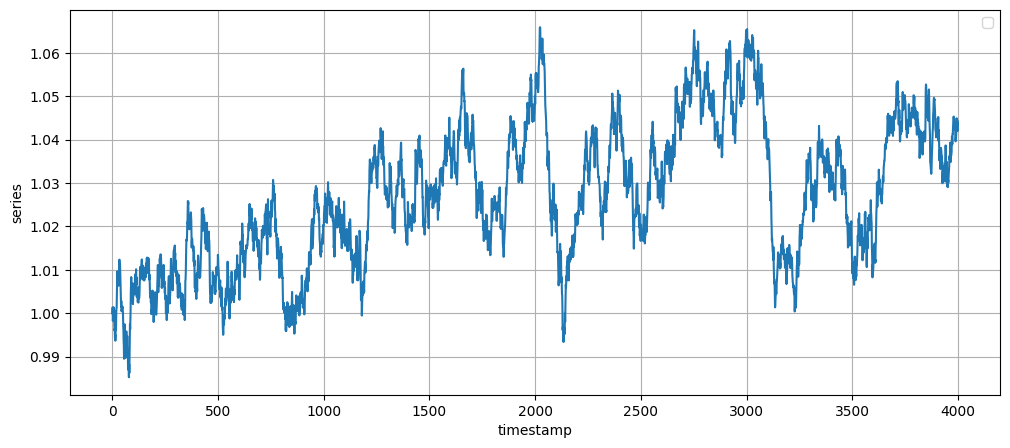

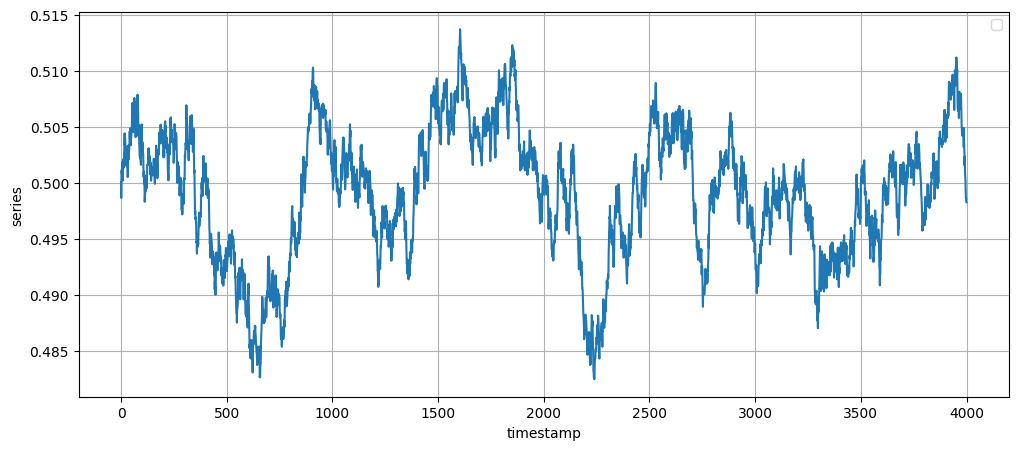

In [ ]:
s, _ = simulate_gbm(
    4000,
    1/250,
    1,
    0,
    0.03
)

plot(
    [s],
    'timestamp',
    'series'
)

plot(
    [(s1)/(s1 + s)],
    'timestamp',
    'series'
)